# Data Loading, EDA, and Single-File Binary Classification

In [1]:
%run data_loader.ipynb

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

Config loaded
preprocess_binary() defined
load_all_datasets() defined
Project root:          /Users/yp_home/Documents/IDS_project
CICIDS2018 folder exists: True
load_cicids2018() defined


## 1. Load All 8 Datasets

In [2]:
datasets = load_all_datasets()

df_monday       = datasets.get("monday")
df_bruteforce   = datasets.get("bruteforce")
df_dos          = datasets.get("dos")
df_infiltration = datasets.get("infiltration")
df_web          = datasets.get("web_attacks")
df_botnet       = datasets.get("botnet")
df_portscan     = datasets.get("portscan")
df_ddos         = datasets.get("ddos")

Loading 8 dataset(s): ['monday', 'bruteforce', 'dos', 'web_attacks', 'infiltration', 'botnet', 'portscan', 'ddos']

  [monday]  Monday-WorkingHours.pcap_ISCX.csv
           raw (529918, 79)  ->  clean (502650, 81)  (attack rate 0.0%)
  [bruteforce]  Tuesday-WorkingHours.pcap_ISCX.csv
           raw (445909, 79)  ->  clean (421626, 81)  (attack rate 2.2%)
  [dos]  Wednesday-workingHours.pcap_ISCX.csv
           raw (692703, 79)  ->  clean (610492, 81)  (attack rate 31.7%)
  [web_attacks]  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
           raw (170366, 79)  ->  clean (164179, 81)  (attack rate 1.3%)
  [infiltration]  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
           raw (288602, 79)  ->  clean (252790, 81)  (attack rate 0.0%)
  [botnet]  Friday-WorkingHours-Morning.pcap_ISCX.csv
           raw (191033, 79)  ->  clean (184044, 81)  (attack rate 1.1%)
  [portscan]  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
           raw (286467, 79)  ->  clea

In [3]:
# Dataset overview
summary_rows = []
for key, df in datasets.items():
    summary_rows.append({
        "Key":           key,
        "Rows":          len(df),
        "Benign":        (df["Label_Binary"] == 0).sum(),
        "Attack":        (df["Label_Binary"] == 1).sum(),
        "Attack Rate %": round(df["Label_Binary"].mean() * 100, 2),
        "Attack Types":  df["Label"].nunique() - 1,
    })
pd.DataFrame(summary_rows)

,Key,Rows,Benign,Attack,Attack Rate %,Attack Types
0,monday,502650,502650,0,0.00,0
1,bruteforce,421626,412476,9150,2.17,2
2,dos,610492,416736,193756,31.74,5
3,web_attacks,164179,162036,2143,1.31,3
4,infiltration,252790,252754,36,0.01,1
5,botnet,184044,182096,1948,1.06,1
6,portscan,213777,123083,90694,42.42,1
7,ddos,223082,95068,128014,57.38,1


## 2. EDA — Web Attacks File

In [4]:
print("Shape:", df_web.shape)
df_web.head()

Shape: (164179, 81)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label_Binary,Source_File
0,389,113095465,48,24,9668,10012,403,0,201.416667,203.548293,...,5.758373e+05,1629110,379,13800000.0,4.277541e+06,16500000,6737603,BENIGN,0,WebAttacks
1,389,113473706,68,40,11364,12718,403,0,167.117647,171.919413,...,5.034269e+05,1424245,325,13800000.0,4.229413e+06,16500000,6945512,BENIGN,0,WebAttacks
2,0,119945515,150,0,0,0,0,0,0.000000,0.000000,...,1.170000e+07,20400000,6,24400000.0,2.430000e+07,60100000,5702188,BENIGN,0,WebAttacks
3,443,60261928,9,7,2330,4221,1093,0,258.888889,409.702161,...,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN,0,WebAttacks
4,53,269,2,2,102,322,51,51,51.000000,0.000000,...,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN,0,WebAttacks


In [5]:
print("Label distribution:")
print(df_web["Label"].value_counts())
print("\nBinary label distribution:")
print(df_web["Label_Binary"].value_counts())

Label distribution:
Label
BENIGN                        162036
Web Attack � Brute Force        1470
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64

Binary label distribution:
Label_Binary
0    162036
1      2143
Name: count, dtype: int64


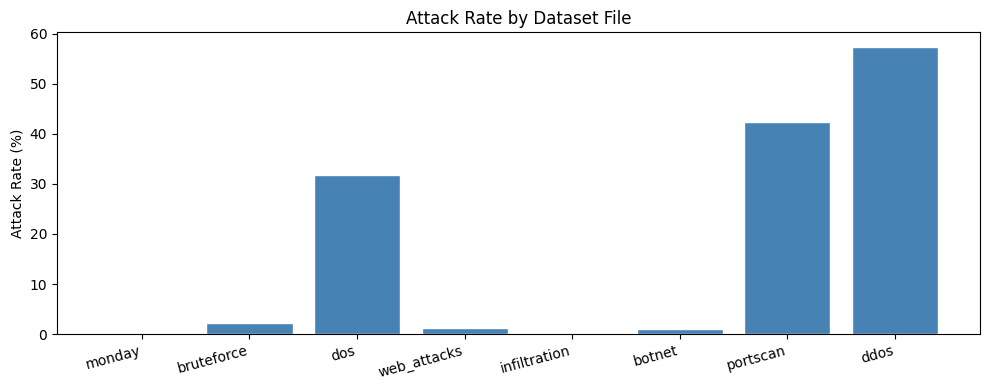

In [6]:
# Attack rate across all files
attack_rates = {k: round(v["Label_Binary"].mean() * 100, 2) for k, v in datasets.items()}

plt.figure(figsize=(10, 4))
plt.bar(attack_rates.keys(), attack_rates.values(), color="steelblue", edgecolor="white")
plt.ylabel("Attack Rate (%)")
plt.title("Attack Rate by Dataset File")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 3. Single-File Binary Classification (Web Attacks)

In [7]:
X = df_web.drop(columns=["Label", "Label_Binary", "Source_File"])
y = df_web["Label_Binary"]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "  X_test:", X_test.shape)
print("Train label counts:\n", y_train.value_counts())

X_train: (131343, 78)   X_test: (32836, 78)
Train label counts:
 Label_Binary
0    129629
1      1714
Name: count, dtype: int64


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr   = log_reg.predict(X_test_scaled)
y_scores_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression")
print("  Accuracy: ", round(accuracy_score(y_test, y_pred_lr), 4))
print("  Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("  Recall:   ", round(recall_score(y_test, y_pred_lr), 4))
print("  F1:       ", round(f1_score(y_test, y_pred_lr), 4))
print("  ROC-AUC:  ", round(roc_auc_score(y_test, y_scores_lr), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression
  Accuracy:  0.9797
  Precision: 0.3914
  Recall:    0.9953
  F1:        0.5618
  ROC-AUC:   0.9975

Confusion Matrix:
 [[31743   664]
 [    2   427]]


In [9]:
rf_model = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf   = rf_model.predict(X_test)
y_scores_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print("  Accuracy: ", round(accuracy_score(y_test, y_pred_rf), 4))
print("  Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("  Recall:   ", round(recall_score(y_test, y_pred_rf), 4))
print("  F1:       ", round(f1_score(y_test, y_pred_rf), 4))
print("  ROC-AUC:  ", round(roc_auc_score(y_test, y_scores_rf), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest
  Accuracy:  0.9998
  Precision: 0.9977
  Recall:    0.9907
  F1:        0.9942
  ROC-AUC:   1.0

Confusion Matrix:
 [[32406     1]
 [    4   425]]


## 4. Feature Importance (Random Forest)

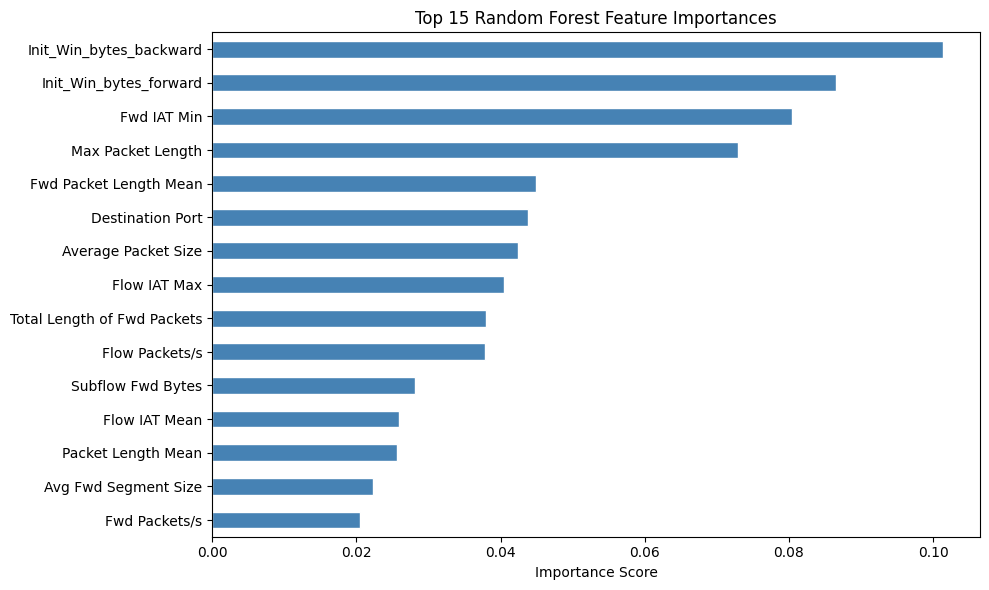

Top 15 features: ['Init_Win_bytes_backward', 'Init_Win_bytes_forward', 'Fwd IAT Min', 'Max Packet Length', 'Fwd Packet Length Mean', 'Destination Port', 'Average Packet Size', 'Flow IAT Max', 'Total Length of Fwd Packets', 'Flow Packets/s', 'Subflow Fwd Bytes', 'Flow IAT Mean', 'Packet Length Mean', 'Avg Fwd Segment Size', 'Fwd Packets/s']


In [10]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = feature_importances.sort_values(ascending=False).head(15)

top_features.sort_values().plot(kind="barh", figsize=(10, 6), color="steelblue", edgecolor="white")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

top_15_features = top_features.index.tolist()
print("Top 15 features:", top_15_features)

## 5. LSTM — Sequence-Based Binary Classification

In [11]:
X_train_top = X_train[top_15_features].copy()
X_test_top  = X_test[top_15_features].copy()

lstm_scaler = StandardScaler()
X_train_top_scaled = lstm_scaler.fit_transform(X_train_top)
X_test_top_scaled  = lstm_scaler.transform(X_test_top)

def create_sequences(X, y, seq_length=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length + 1):
        X_seq.append(X[i : i + seq_length])
        y_seq.append(y.iloc[i + seq_length - 1])
    return np.array(X_seq), np.array(y_seq)

SEQ_LEN = 10
X_train_seq, y_train_seq = create_sequences(X_train_top_scaled, y_train.reset_index(drop=True), SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(X_test_top_scaled,  y_test.reset_index(drop=True),  SEQ_LEN)

print("Train sequences:", X_train_seq.shape)
print("Test  sequences:", X_test_seq.shape)

Train sequences: (131334, 10, 15)
Test  sequences: (32827, 10, 15)


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_seq,  dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test_seq,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor,  y_test_tensor),  batch_size=64, shuffle=False)

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc   = nn.Linear(hidden_size, 1)
    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return self.fc(hn[-1]).squeeze(1)

model = LSTMClassifier(input_size=X_train_seq.shape[2]).to(device)

pos_weight = torch.tensor(
    [(y_train_seq == 0).sum() / (y_train_seq == 1).sum()], dtype=torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Device: cpu


In [13]:
NUM_EPOCHS = 5
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  Loss: {running_loss / len(train_loader):.4f}")

Epoch [1/5]  Loss: 0.4608
Epoch [2/5]  Loss: 0.2405
Epoch [3/5]  Loss: 0.1847
Epoch [4/5]  Loss: 0.1591
Epoch [5/5]  Loss: 0.1421


In [14]:
model.eval()
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        probs = torch.sigmoid(model(X_batch.to(device)))
        preds = (probs >= 0.5).float()
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("LSTM")
print("  Accuracy: ", round(accuracy_score(all_labels, all_preds), 4))
print("  Precision:", round(precision_score(all_labels, all_preds), 4))
print("  Recall:   ", round(recall_score(all_labels, all_preds), 4))
print("  F1:       ", round(f1_score(all_labels, all_preds), 4))
print("  ROC-AUC:  ", round(roc_auc_score(all_labels, all_probs), 4))

LSTM
  Accuracy:  0.9772
  Precision: 0.3592
  Recall:    0.951
  F1:        0.5214
  ROC-AUC:   0.9963


## 6. Results Summary

In [15]:
results_df = pd.DataFrame([
    {"Model": "Logistic Regression", "Accuracy": 0.9800, "Precision": 0.3939,
     "Recall": 0.9907, "F1": 0.5637, "ROC_AUC": 0.9973, "FP": 654, "FN": 4},
    {"Model": "Random Forest",       "Accuracy": 0.9998, "Precision": 0.9953,
     "Recall": 0.9883, "F1": 0.9918, "ROC_AUC": 1.0000, "FP": 2,   "FN": 5},
    {"Model": "LSTM",                "Accuracy": 0.9810, "Precision": 0.4018,
     "Recall": 0.9322, "F1": 0.5616, "ROC_AUC": 0.9958, "FP": 594, "FN": 29},
])
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,FP,FN
0,Logistic Regression,0.9800,0.3939,0.9907,0.5637,0.9973,654,4
1,Random Forest,0.9998,0.9953,0.9883,0.9918,1.0000,2,5
2,LSTM,0.9810,0.4018,0.9322,0.5616,0.9958,594,29


## Additional Dataset Added

In addition to the original CICIDS2017 files, I added CSE-CIC-IDS2018 as a second intrusion detection dataset. The new files were stored separately under `data/cse_cic_ids2018/` so the original CICIDS2017 loading process would not break. The 2018 dataset is loaded through a separate helper function in `data_loader.ipynb`.